In [19]:
# Import libraries
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [20]:
# Load dataset
df = pd.read_csv("ranoush_data.csv")
df.head()

,Restaurant,Dish,Price,Course
0,Ranoush,Hummus,$ 9.99,Appetizers
1,Ranoush,Baba Ganoush,$ 9.99,Appetizers
2,Ranoush,Labneh,$ 9.99,Appetizers
3,Ranoush,Tabbouleh,$ 9.99,Appetizers
4,Ranoush,Muhammara,$ 9.99,Appetizers


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2363 entries, 0 to 2362
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  2363 non-null   object
 1   Dish        2363 non-null   object
 2   Price       2261 non-null   object
 3   Course      2363 non-null   object
dtypes: object(4)
memory usage: 74.0+ KB


In [22]:
# Clean price data
def parse_price(x):
    """
    Turns strings like '$ 9.99', ' $ 9.99 ', '$9.99', '9.99', or blank into float/NaN.
    """
    if pd.isna(x):
        return pd.NA
    s = str(x)
    m = re.search(r"(\d+(?:\.\d+)?)", s.replace(",", ""))
    return float(m.group(1)) if m else pd.NA

df = df.copy()
df["PriceNum"] = df["Price"].apply(parse_price)
df = df.dropna(subset=["PriceNum", "Course", "Restaurant"])

df.head()

,Restaurant,Dish,Price,Course,PriceNum
0,Ranoush,Hummus,$ 9.99,Appetizers,9.99
1,Ranoush,Baba Ganoush,$ 9.99,Appetizers,9.99
2,Ranoush,Labneh,$ 9.99,Appetizers,9.99
3,Ranoush,Tabbouleh,$ 9.99,Appetizers,9.99
4,Ranoush,Muhammara,$ 9.99,Appetizers,9.99


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2260 entries, 0 to 2362
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  2260 non-null   object
 1   Dish        2260 non-null   object
 2   Price       2260 non-null   object
 3   Course      2260 non-null   object
 4   PriceNum    2260 non-null   object
dtypes: object(5)
memory usage: 105.9+ KB


In [24]:
TARGET = "Ranoush"

# Keep only courses where Ranoush actually has items (so comparisons make sense)
courses = sorted(df.loc[df["Restaurant"].eq(TARGET), "Course"].unique())

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\2055467544.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(price_lists, labels=restaurants, showfliers=True)


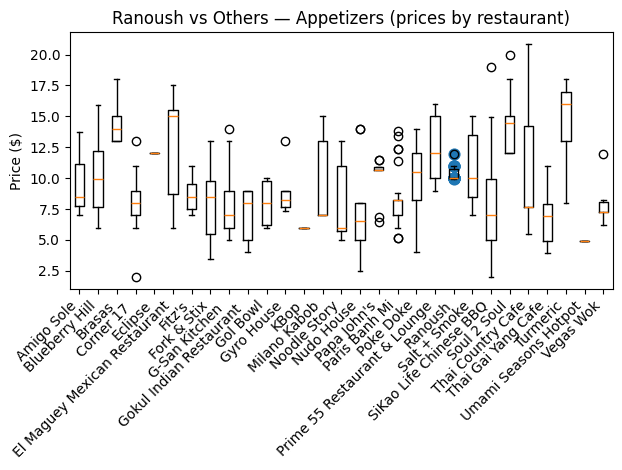

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\2055467544.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(price_lists, labels=restaurants, showfliers=True)


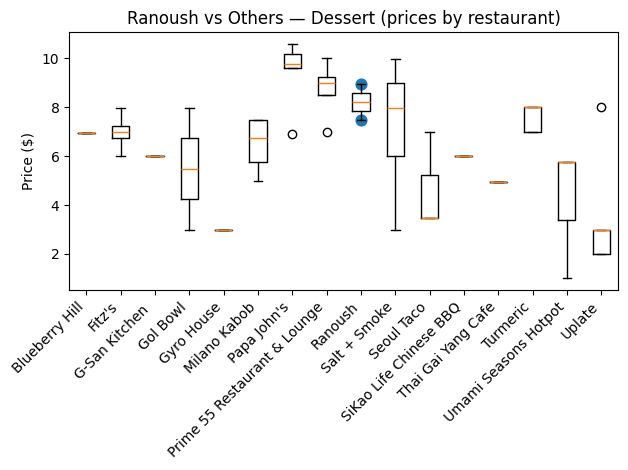

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\2055467544.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(price_lists, labels=restaurants, showfliers=True)


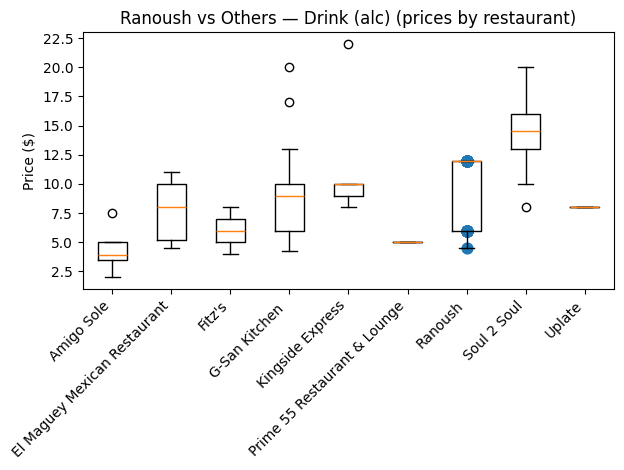

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\2055467544.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(price_lists, labels=restaurants, showfliers=True)


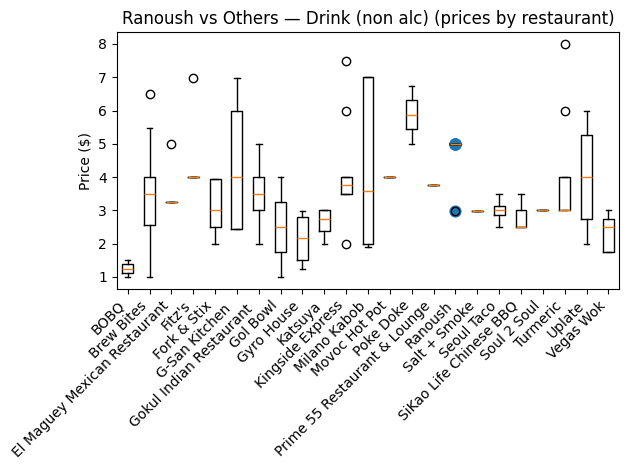

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\2055467544.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(price_lists, labels=restaurants, showfliers=True)


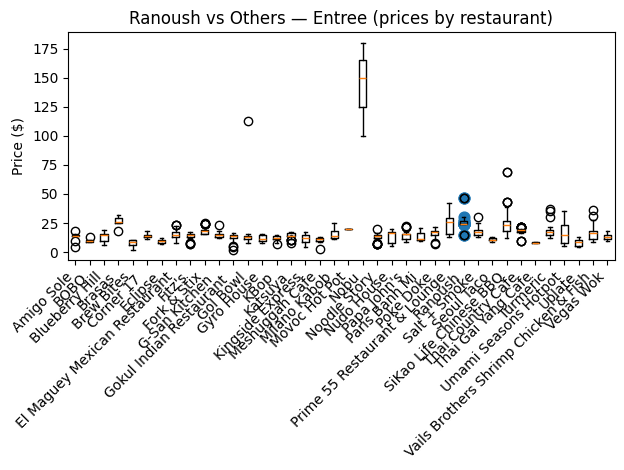

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\2055467544.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(price_lists, labels=restaurants, showfliers=True)


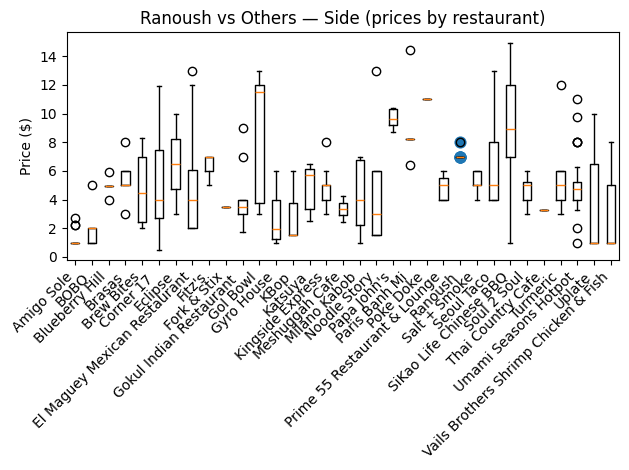

In [25]:
# Ranoush vs all restaurants by course (boxplot + Ranoush points) ----
for course in courses:
    d = df[df["Course"].eq(course)].copy()
    if d.empty:
        continue

    # Boxplot per restaurant for this course
    restaurants = sorted(d["Restaurant"].unique())
    price_lists = [d.loc[d["Restaurant"].eq(r), "PriceNum"].tolist() for r in restaurants]

    plt.figure()
    plt.boxplot(price_lists, labels=restaurants, showfliers=True)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Price ($)")
    plt.title(f"{TARGET} vs Others — {course} (prices by restaurant)")

    # Overlay Ranoush as a scatter column (so it pops)
    if TARGET in restaurants:
        x = restaurants.index(TARGET) + 1
        y = d.loc[d["Restaurant"].eq(TARGET), "PriceNum"].values
        plt.scatter([x] * len(y), y, s=60)

    plt.tight_layout()
    plt.show()


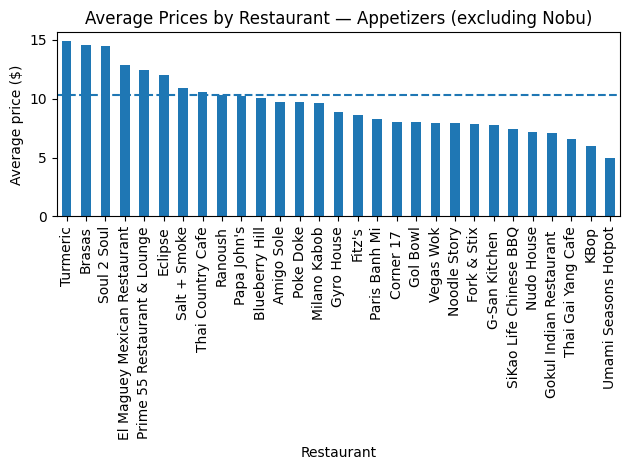

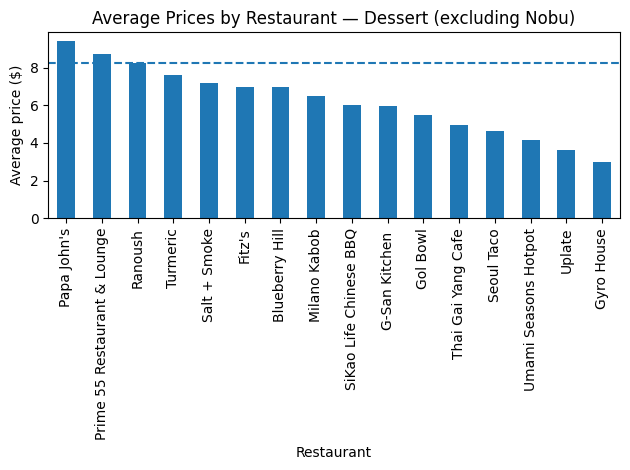

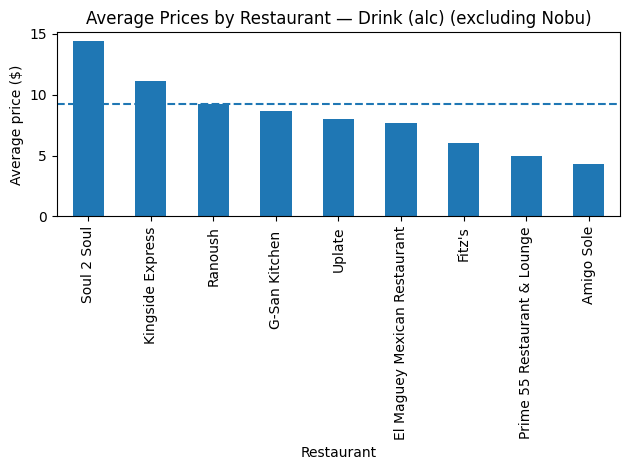

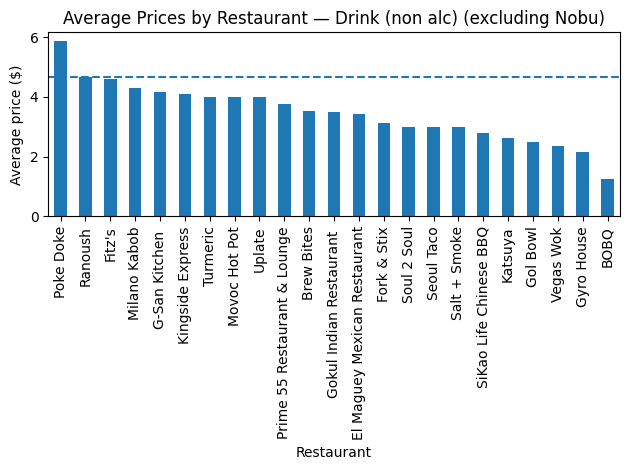

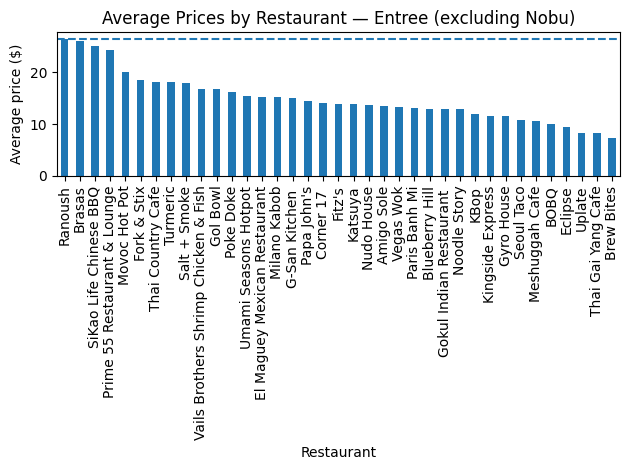

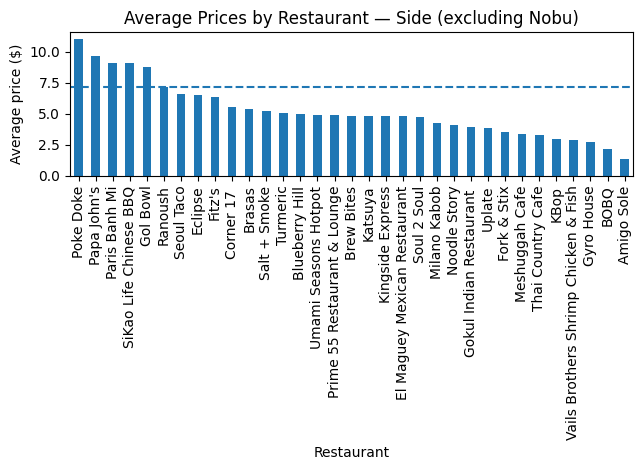

In [41]:
# Exclude Nobu
df2 = df.loc[~df["Restaurant"].astype(str).str.strip().eq("Nobu")].copy()

# Only plot courses where Ranoush exists (in df2)
courses = sorted(df2.loc[df2["Restaurant"].eq(TARGET), "Course"].unique())

# Single bar chart per course (avg price per restaurant), excluding Nobu
for course in courses:
    d = df2[df2["Course"].eq(course)]
    if d.empty:
        continue

    means = (
        d.groupby("Restaurant")["PriceNum"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure()
    means.plot(kind="bar")
    plt.ylabel("Average price ($)")
    plt.title(f"Average Prices by Restaurant — {course} (excluding Nobu)")

    # Emphasize Ranoush with a horizontal line
    if TARGET in means.index:
        plt.axhline(means.loc[TARGET], linestyle="--")

    plt.tight_layout()
    plt.show()


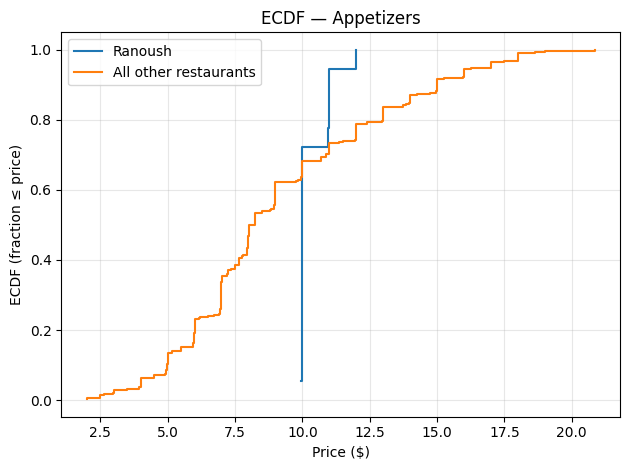

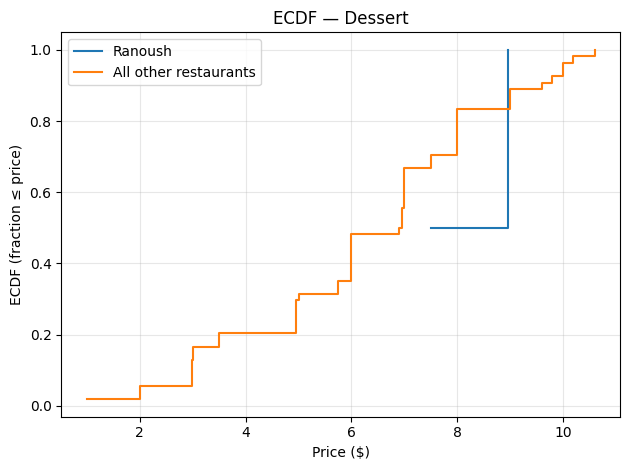

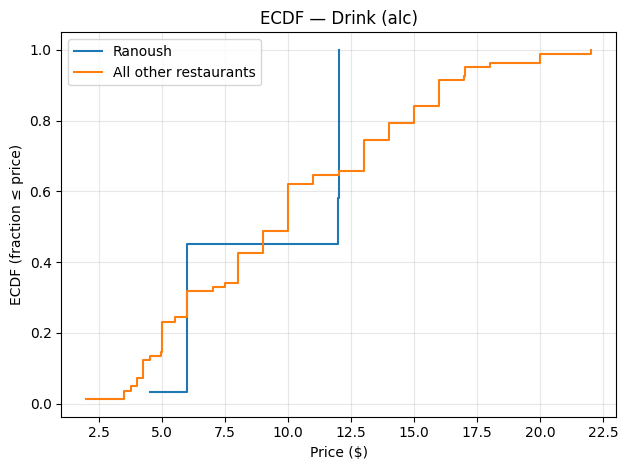

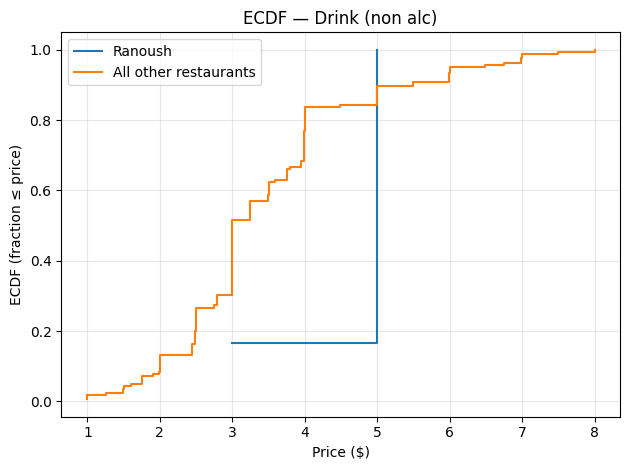

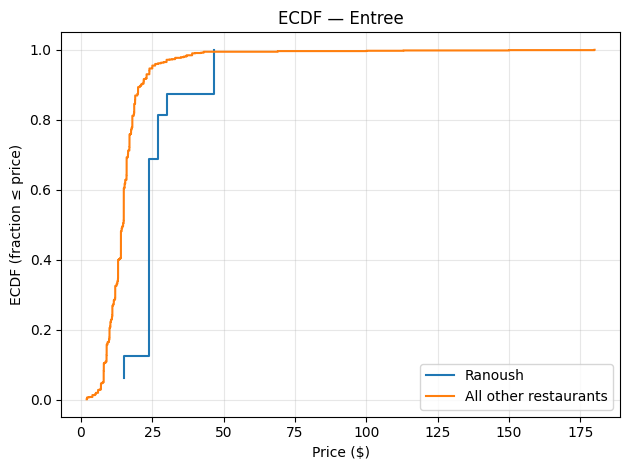

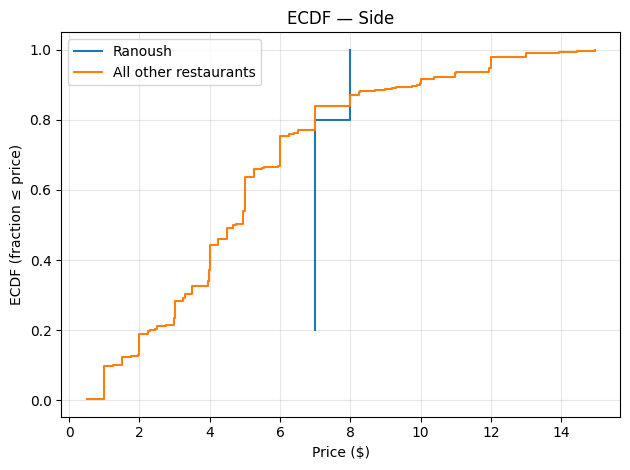

In [29]:
def ecdf(values):
    x = np.sort(np.asarray(values, dtype=float))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

df = df.copy()
df["PriceNum"] = df["Price"].apply(parse_price)
df = df.dropna(subset=["PriceNum", "Course", "Restaurant"])

# Only plot courses where Ranoush exists (so comparisons are meaningful)
courses = sorted(df.loc[df["Restaurant"].eq(TARGET), "Course"].unique())

for course in courses:
    d = df[df["Course"].eq(course)]
    ran = d.loc[d["Restaurant"].eq(TARGET), "PriceNum"]
    oth = d.loc[~d["Restaurant"].eq(TARGET), "PriceNum"]

    if ran.empty or oth.empty:
        continue

    x_r, y_r = ecdf(ran)
    x_o, y_o = ecdf(oth)

    plt.figure()
    plt.step(x_r, y_r, where="post", label=TARGET)
    plt.step(x_o, y_o, where="post", label="All other restaurants")

    plt.xlabel("Price ($)")
    plt.ylabel("ECDF (fraction ≤ price)")
    plt.title(f"ECDF — {course}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

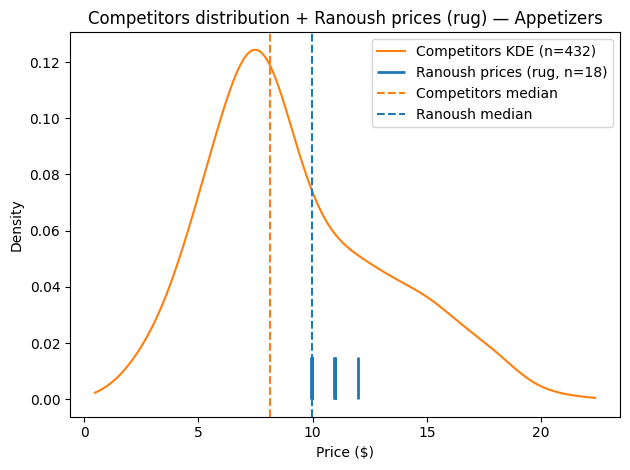

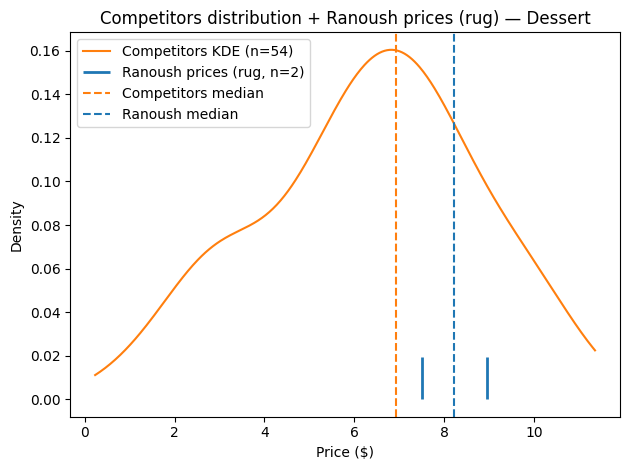

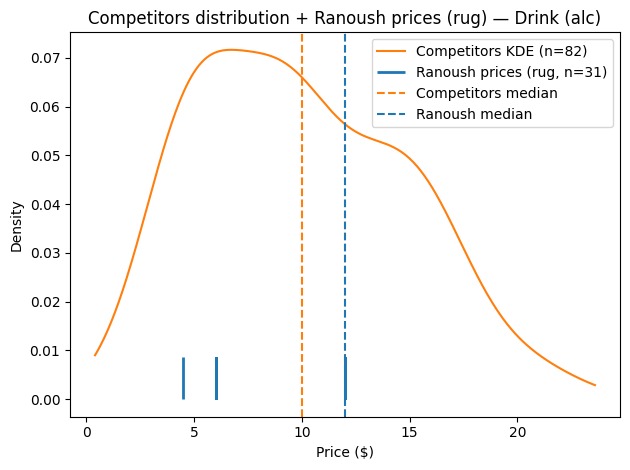

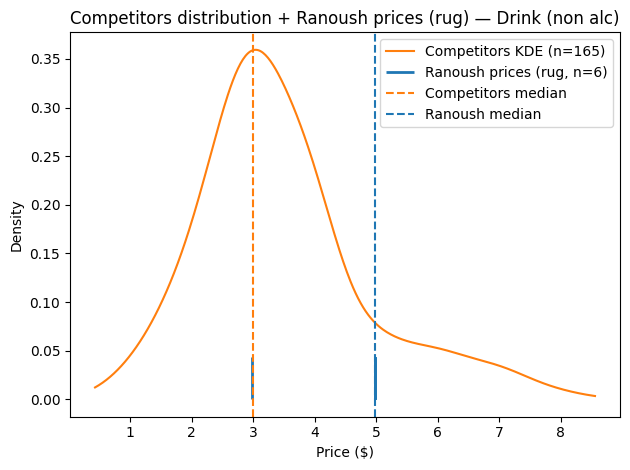

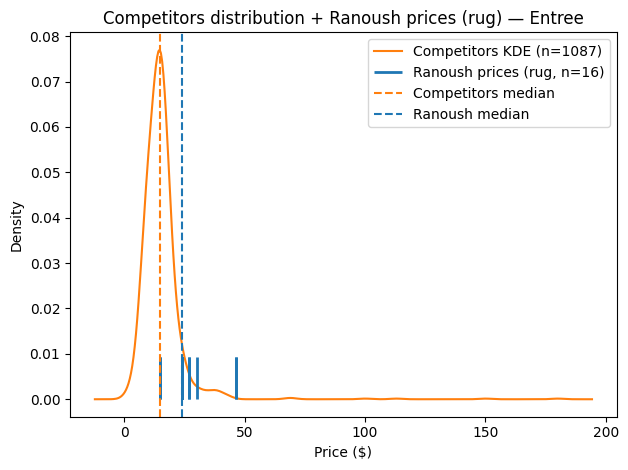

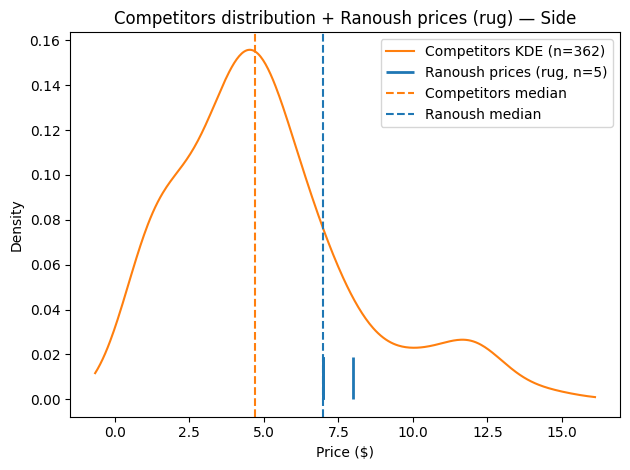

In [35]:
def kde_gaussian(x, grid, bw=None):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2:
        return np.zeros_like(grid)

    if bw is None:
        std = np.std(x, ddof=1)
        if std == 0:
            std = 1e-6
        bw = 1.06 * std * (n ** (-1/5))

    z = (grid[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * z**2).sum(axis=1) / (n * bw * np.sqrt(2*np.pi))
    return dens

df = df.copy()
df["PriceNum"] = df["Price"].apply(parse_price)
df = df.dropna(subset=["PriceNum", "Course", "Restaurant"])

courses = sorted(df.loc[df["Restaurant"].eq(TARGET), "Course"].unique())

for course in courses:
    d = df[df["Course"].eq(course)]
    ran = d.loc[d["Restaurant"].eq(TARGET), "PriceNum"].astype(float).to_numpy()
    oth = d.loc[~d["Restaurant"].eq(TARGET), "PriceNum"].astype(float).to_numpy()

    if len(ran) == 0 or len(oth) == 0:
        continue

    all_vals = np.concatenate([ran, oth])
    lo, hi = float(all_vals.min()), float(all_vals.max())
    pad = 0.08 * (hi - lo) if hi > lo else 1.0
    lo, hi = lo - pad, hi + pad
    grid = np.linspace(lo, hi, 400)

    # KDE for competitors
    dens_o = kde_gaussian(oth, grid)

    plt.figure()

    # Competitors KDE (single line)
    plt.plot(grid, dens_o, color="tab:orange", label=f"Competitors KDE (n={len(oth)})")

    # Ranoush rug + legend entry
    ymax = max(dens_o.max(), 1e-6)
    rug_height = 0.12 * ymax
    plt.vlines(
        ran, 0, rug_height,
        color="tab:blue",
        linewidth=2,
        label=f"{TARGET} prices (rug, n={len(ran)})"
    )

    # Median lines (match group colors) + legend entries
    plt.axvline(
        np.median(oth),
        linestyle="--",
        color="tab:orange",
        label="Competitors median"
    )
    plt.axvline(
        np.median(ran),
        linestyle="--",
        color="tab:blue",
        label=f"{TARGET} median"
    )

    plt.xlabel("Price ($)")
    plt.ylabel("Density")
    plt.title(f"Competitors distribution + {TARGET} prices (rug) — {course}")
    plt.legend()
    plt.tight_layout()
    plt.show()

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\3908687215.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


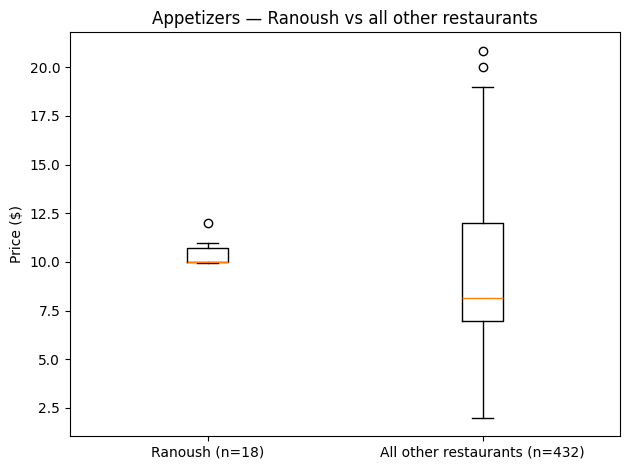

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\3908687215.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


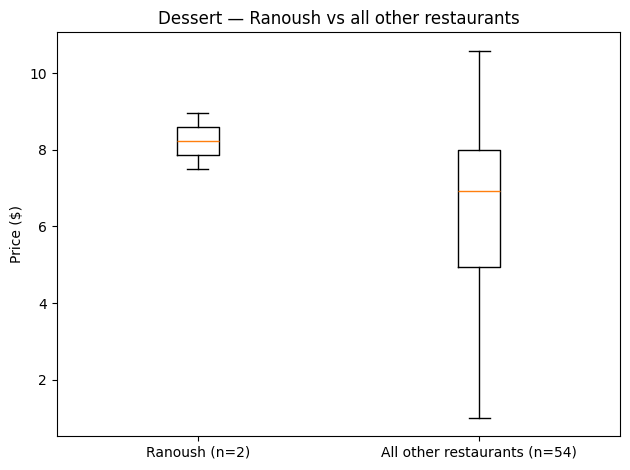

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\3908687215.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


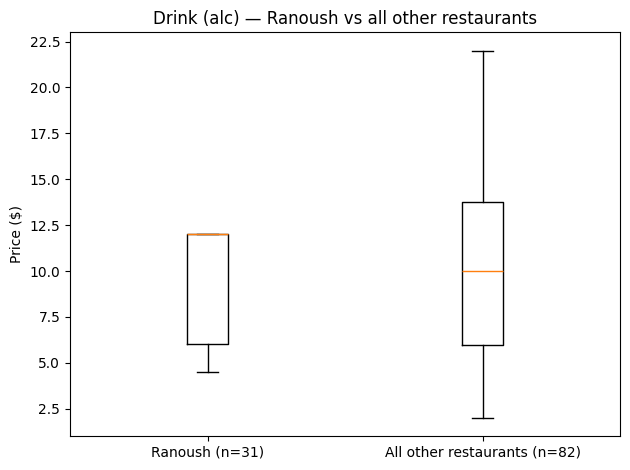

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\3908687215.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


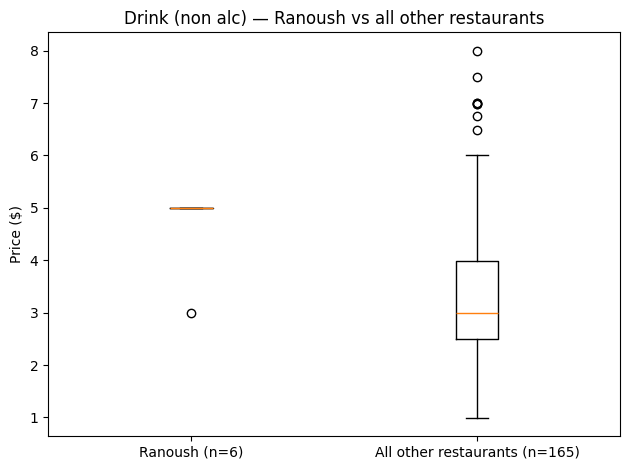

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\3908687215.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


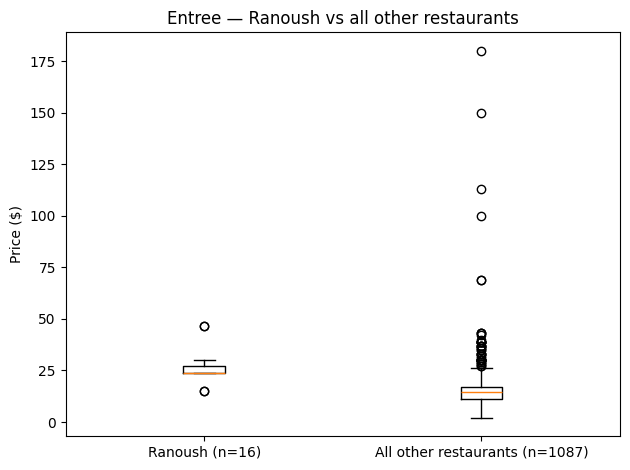

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\3908687215.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


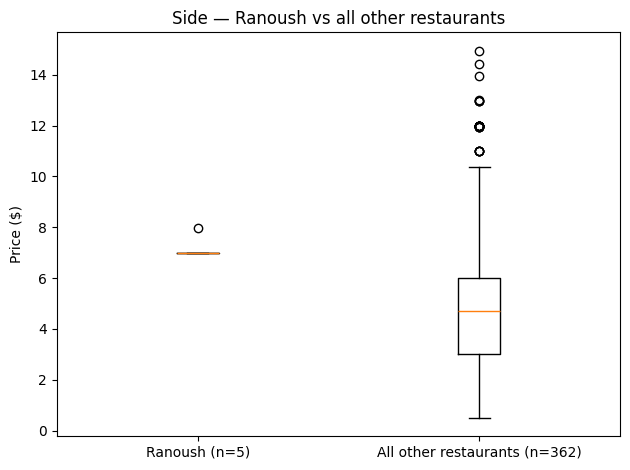

In [38]:
courses = sorted(df.loc[df["Restaurant"].eq(TARGET), "Course"].unique())

for course in courses:
    d = df[df["Course"].eq(course)]

    ran = d.loc[d["Restaurant"].eq(TARGET), "PriceNum"].astype(float)
    oth = d.loc[~d["Restaurant"].eq(TARGET), "PriceNum"].astype(float)

    if ran.empty or oth.empty:
        continue

    plt.figure()
    plt.boxplot(
        [ran.to_numpy(), oth.to_numpy()],
        labels=[f"{TARGET} (n={len(ran)})", f"All other restaurants (n={len(oth)})"],
        showfliers=True
    )
    plt.ylabel("Price ($)")
    plt.title(f"{course} — {TARGET} vs all other restaurants")
    plt.tight_layout()
    plt.show()

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\1080534662.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


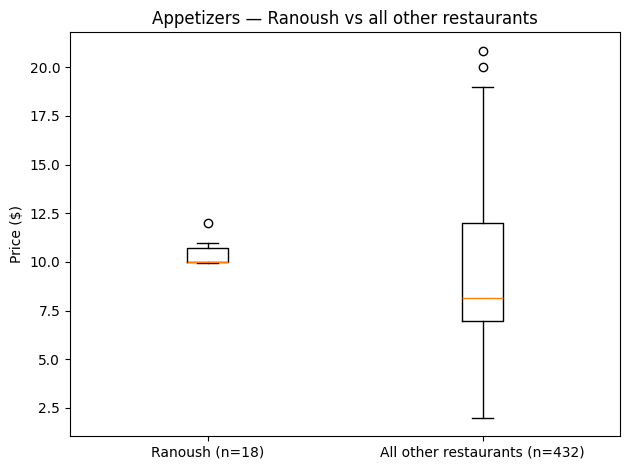

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\1080534662.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


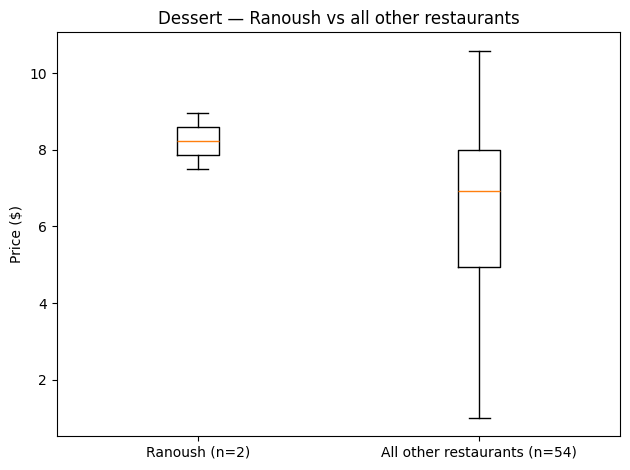

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\1080534662.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


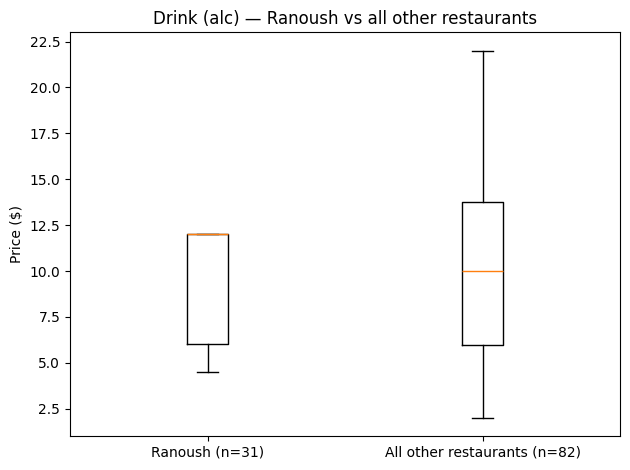

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\1080534662.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


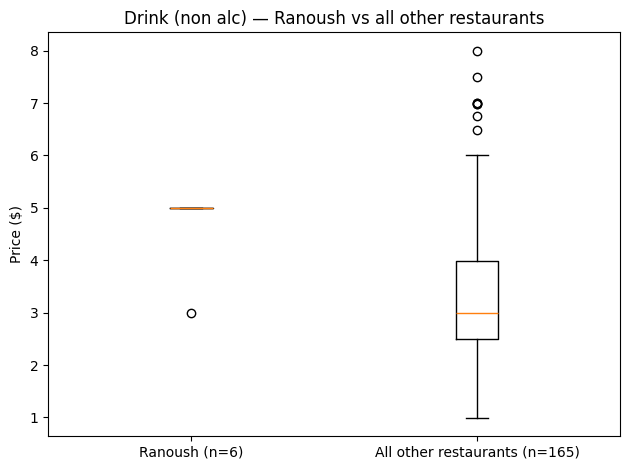

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\1080534662.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


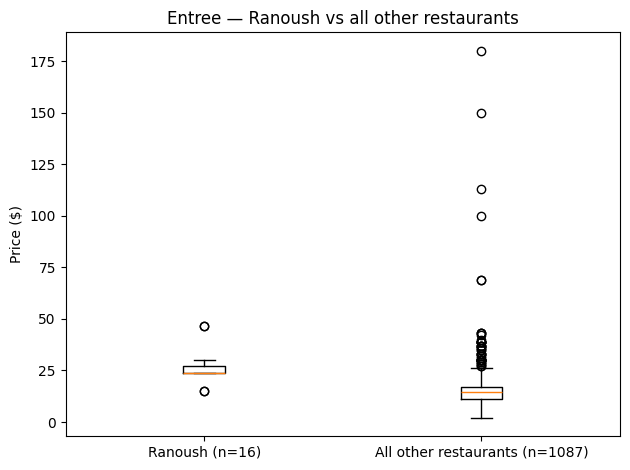

C:\Users\mleen\AppData\Local\Temp\ipykernel_22516\1080534662.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


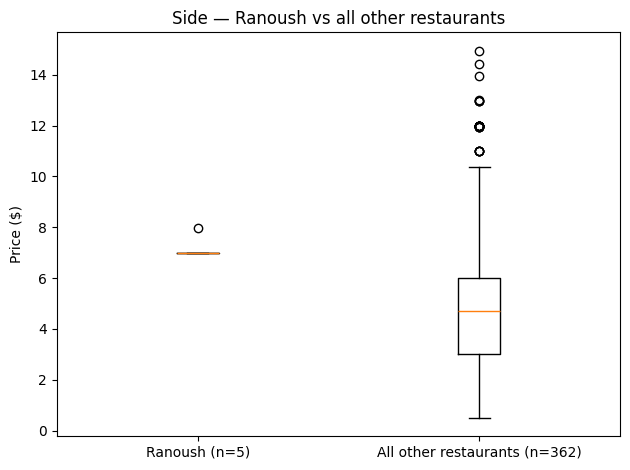

In [40]:
courses = sorted(df.loc[df["Restaurant"].eq(TARGET), "Course"].unique())

df2 = df.loc[~df["Restaurant"].astype(str).str.strip().eq("Nobu")].copy()

for course in courses:
    d = df[df["Course"].eq(course)]

    ran = d.loc[d["Restaurant"].eq(TARGET), "PriceNum"].astype(float)
    oth = d.loc[~d["Restaurant"].eq(TARGET), "PriceNum"].astype(float)

    if ran.empty or oth.empty:
        continue

    plt.figure()
    plt.boxplot(
        [ran.to_numpy(), oth.to_numpy()],
        labels=[f"{TARGET} (n={len(ran)})", f"All other restaurants (n={len(oth)})"],
        showfliers=True
    )
    plt.ylabel("Price ($)")
    plt.title(f"{course} — {TARGET} vs all other restaurants")
    plt.tight_layout()
    plt.show()